# AB Test Analysis: Feed Recommendation Algorithms

## Постановка задачи

Команда ML разработала два новых алгоритма
рекомендаций постов в ленте новостей:

**Алгоритм A (группа 2):** показывает пользователю
посты наиболее похожие на те которые он лайкал.

**Алгоритм B (группа 3):** показывает пользователю
посты которые лайкали похожие на него пользователи.

**Гипотеза:** новые алгоритмы рекомендаций
сделают ленту интереснее для пользователей
и приведут к росту CTR.

**Задача аналитика:**
1. Проверить корректность системы сплитования
   через АА-тест
2. Оценить эффект каждого алгоритма на CTR
   несколькими статистическими методами
3. Сравнить методы между собой и объяснить
   различия в результатах
4. Дать обоснованную рекомендацию —
   раскатывать ли алгоритм на всех пользователей

**Метрики:**
- Главная: CTR = лайки / просмотры
- Вспомогательные: DAU, количество просмотров, количество лайков

**Периоды:**
- АА-тест: 24.04 — 30.04.2026 (группы 2 и 3)
- АБ-тест: 01.05 — 07.05.2026 (группы 1 и 2)
- Линеаризация: 01.05 — 07.05.2026
  (группы 0/3 и 1/2)

**Гипотезы:**

H₀: CTR в экспериментальной группе равен
    CTR в контрольной группе

H₁: CTR в экспериментальной группе отличается
    от CTR в контрольной группе

## Загрузка и проверка данных

In [57]:
import pandas as pd
import pandahouse as ph
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [58]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

Выгружаем данные за два периода:
- АА-тест: 24.04–30.04.2026 (группы 2 и 3)
- АБ-тест: 01.05–07.05.2026 (группы 0, 1, 2, 3)

Агрегируем по пользователям — считаем лайки,
просмотры и CTR для каждого юзера.

In [59]:
q_ab = """
SELECT 
    exp_group,
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20260520.feed_actions
WHERE toDate(time) BETWEEN '2026-05-01' AND '2026-05-07'
    AND exp_group IN (0, 1, 2, 3)
GROUP BY exp_group, user_id
"""

df_ab = ph.read_clickhouse(q_ab, connection=connection)

rows_per_user = df_ab.groupby(['exp_group', 'user_id']).size()
print(f"Макс строк на пользователя: {rows_per_user.max()}")

Макс строк на пользователя: 1


In [60]:
df_ab.head()

,exp_group,user_id,likes,views,ctr
0,3,115383,12,44,0.272727
1,1,18392,7,32,0.218750
2,3,123580,2,11,0.181818
3,2,131473,9,108,0.083333
4,2,32420,13,44,0.295455


Проверяем корректность данных перед анализом:
пропуски, размеры групп, диапазон CTR,
дубликаты и пересечения между группами.

In [61]:
print(df_ab.isnull().sum())

exp_group    0
user_id      0
likes        0
views        0
ctr          0
dtype: int64


In [62]:
print(df_ab.dtypes)

exp_group       int8
user_id       uint32
likes         uint64
views         uint64
ctr          float64
dtype: object


In [63]:
df_ab.shape

(39819, 5)

In [64]:
print(f'Строк: {len(df_ab)}, пользователей: {df_ab.user_id.nunique()}')

Строк: 39819, пользователей: 39819


In [65]:
df_ab.groupby('exp_group')['user_id'].nunique()

exp_group
0     9920
1    10020
2     9877
3    10002
Name: user_id, dtype: int64

In [66]:
print(f"Мин CTR: {df_ab.ctr.min()}")
print(f"Макс CTR: {df_ab.ctr.max()}")

Мин CTR: 0.0
Макс CTR: 0.9


In [67]:
print(f"Нулевые просмотры: {(df_ab.views == 0).sum()}")

Нулевые просмотры: 0


In [68]:
print(f"CTR > 1: {(df_ab.ctr > 1).sum()}")

CTR > 1: 0


In [69]:
df_ab = df_ab[df_ab.views > 0].copy()

print(f'Строки после очистки: {len(df_ab)}')
print(f'Макс CTR: {df_ab.ctr.max():.4f}')
print(f'CTR > 1: {(df_ab.ctr > 1).sum()}')

Строки после очистки: 39819
Макс CTR: 0.9000
CTR > 1: 0


In [70]:
duplicates = df_ab.groupby('user_id')['exp_group'].nunique()
print(f"Юзеры в нескольких группах: {(duplicates > 1).sum()}")

Юзеры в нескольких группах: 0


In [71]:
group_1 = set(df_ab[df_ab.exp_group == 1].user_id)
group_2 = set(df_ab[df_ab.exp_group == 2].user_id)

intersection = group_1 & group_2
print(f"Пересечение групп 1 и 2: {len(intersection)}")

Пересечение групп 1 и 2: 0


### Результаты проверки качества

| Проверка | Результат |
|---|---|
| Пропуски | Отсутствуют ✅ |
| Размеры групп | Сбалансированы (~12 000 юзеров) ✅ |
| Нулевые просмотры | 2 записи — удалены ⚠️ |
| CTR диапазон | [0, 1] после очистки ✅ |

Обнаружено 2 пользователя с нулевыми просмотрами
и CTR = inf — вероятно баг в логировании.
Записи исключены из анализа как некорректные.

Данные готовы к анализу.

## Проверка системы сплитования (АА-тест)

Перед проведением AB-теста необходимо убедиться
что система сплитования работает корректно —
группы статистически эквивалентны и не различаются
между собой до начала воздействия.

Для этого проводим АА-тест на данных за период
24.04 — 30.04.2026, группы 2 и 3.

В АА-тесте обе группы получают одинаковый алгоритм —
никакого воздействия нет. Если система сплитования
работает корректно, статистически значимые различия
между группами должны встречаться только в ~5%
случаев (ошибка первого рода при α = 0.05).

Метод: многократно извлекаем подвыборки по 500
пользователей из каждой группы, проводим t-тест
и смотрим на распределение p-value.

Если FPR ≈ 5% → сплитование корректно →
можно доверять результатам AB-теста.

In [72]:
q_aa = """
SELECT exp_group, user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20260520.feed_actions
WHERE toDate(time) BETWEEN '2026-04-24' AND '2026-04-30'
    AND exp_group IN (2, 3)
GROUP BY exp_group, user_id
"""

df_aa = ph.read_clickhouse(q_aa, connection=connection)

rows_per_user = df_aa.groupby(['exp_group', 'user_id']).size()
print(f"Макс строк на пользователя: {rows_per_user.max()}")

Макс строк на пользователя: 1


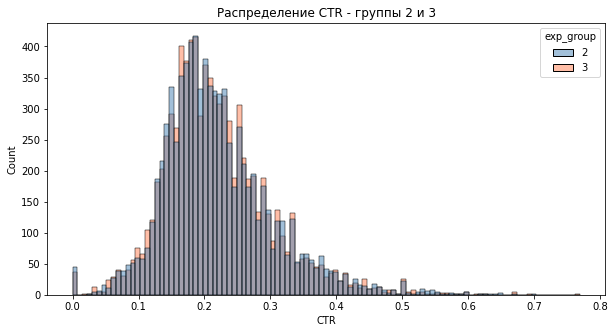

In [73]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_aa[df_aa.exp_group.isin([2, 3])],
    x='ctr',
    hue='exp_group',
    palette=['steelblue', 'coral'],
    alpha=0.5
)

plt.title('Распределение CTR - группы 2 и 3')
plt.xlabel('CTR')
plt.show()

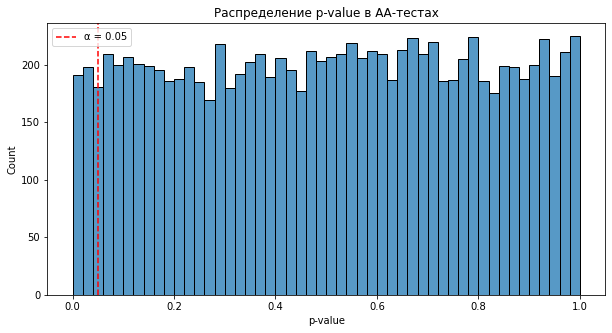

Доля p-value < 0.05: 0.0477
Ожидаем около 0.05 (5%)


In [74]:
group_2 = df_aa[df_aa.exp_group == 2]
group_3 = df_aa[df_aa.exp_group == 3]

p_values = []    

for _ in range(10000):
    
    sample_2 = group_2.sample(500, replace=False)
    sample_3 = group_3.sample(500, replace=False)
    
    _, p_value = stats.ttest_ind(
        sample_2['ctr'],
        sample_3['ctr'],
        equal_var=False
    )    
    p_values.append(p_value)
    
p_values = np.array(p_values)

plt.figure(figsize=(10, 5))
sns.histplot(p_values, bins=50)
plt.axvline(0.05, color='red', linestyle='--', 
            label='α = 0.05')
plt.title('Распределение p-value в АА-тестах')
plt.xlabel('p-value')
plt.legend()
plt.show()

fpr = (p_values < 0.05).mean()
print(f"Доля p-value < 0.05: {fpr:.4f}")
print(f"Ожидаем около 0.05 (5%)")

### Вывод

По результатам 10000 симуляций FPR составил 0.0477 - 
близко к теоретически ожидаемым 0.05.

Распределение p-value распределение на [0, 1] -
что соответствует поведению пр верной H₀.

Система сплитования работает корректно - 
группы 2 и 3 статистически эквивалентны 
по поведению AB-теста. Результатам
эксперимента можно доверять.

## Исследовательский анализ данных

### CTR

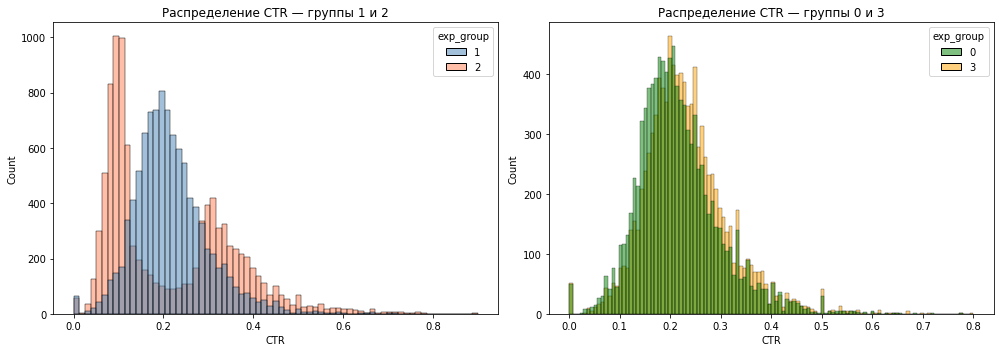

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_ab[df_ab.exp_group.isin([1, 2])],
    x='ctr',
    hue='exp_group',
    palette=['steelblue', 'coral'],
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title('Распределение CTR — группы 1 и 2')
axes[0].set_xlabel('CTR')

sns.histplot(
    data=df_ab[df_ab.exp_group.isin([0, 3])],
    x='ctr',
    hue='exp_group',
    palette=['green', 'orange'],
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title('Распределение CTR — группы 0 и 3')
axes[1].set_xlabel('CTR')

plt.tight_layout()
plt.show()

**Группы 1 и 2:**

Группа 1 (контроль) имеет одномодальное
правосторонне скошенное распределение —
пик около 0.19-0.20, длинный правый хвост.

Группа 2 (алгоритм A) демонстрирует
бимодальное распределение — два выраженных пика:
основной около 0.05-0.10 и второй около 0.30-0.35.

Это интересное наблюдение — бимодальность
может говорить о том что алгоритм A
по-разному влияет на разные сегменты пользователей:
одни остались с низким CTR как в контроле,
другие значительно повысили свой CTR.

Это повод дополнительно проверить эффект
в разрезе сегментов пользователей
после основного анализа.

**Группы 0 и 3:**
Распределения визуально практически совпадают —
предварительный сигнал отсутствия эффекта
алгоритма B. Проверим статистическими тестами.

**Описательная статистика по группам**

In [76]:
stats_df = df_ab[df_ab.exp_group.isin([1, 2])]\
    .groupby('exp_group')['ctr']\
    .agg([
        ('Среднее',     'mean'),
        ('Медиана',     'median'),
        ('Дисперсия',   'var'),
        ('Std',         'std'),
        ('Мин',         'min'),
        ('Макс',        'max'),
        ('Q25',         lambda x: x.quantile(0.25)),
        ('Q75',         lambda x: x.quantile(0.75)),
    ]).round(4)

print("Группы 1 и 2:")
print(stats_df)

print("\nГруппы 0 и 3:")
stats_df_03 = df_ab[df_ab.exp_group.isin([0, 3])]\
    .groupby('exp_group')['ctr']\
    .agg([
        ('Среднее',   'mean'),
        ('Медиана',   'median'),
        ('Дисперсия', 'var'),
        ('Std',       'std'),
        ('Мин',       'min'),
        ('Макс',      'max'),
        ('Q25',       lambda x: x.quantile(0.25)),
        ('Q75',       lambda x: x.quantile(0.75)),
    ]).round(4)

print(stats_df_03)

Группы 1 и 2:
           Среднее  Медиана  Дисперсия     Std  Мин    Макс     Q25     Q75
exp_group                                                                  
1           0.2168   0.2059     0.0069  0.0830  0.0  0.7222  0.1636  0.2579
2           0.2161   0.1533     0.0204  0.1429  0.0  0.9000  0.0968  0.3235

Группы 0 и 3:
           Среднее  Медиана  Дисперсия     Std  Мин    Макс     Q25     Q75
exp_group                                                                  
0           0.2169   0.2054     0.0066  0.0815  0.0  0.7778  0.1636  0.2571
3           0.2332   0.2222     0.0070  0.0839  0.0  0.8000  0.1797  0.2759


**Группы 1 и 2:**

Средние CTR практически одинаковы
(0.2168 vs 0.2161) — простой t-тест
на среднем может не показать различий.

Однако медиана группы 2 значительно ниже
(0.1533 vs 0.2059) — типичный пользователь
группы 2 имеет меньший CTR.

При этом дисперсия группы 2 в 2.4 раза выше
(0.0204 vs 0.0069) и Q75 выше (0.3235 vs 0.2579) —
у группы 2 больше пользователей с высоким CTR.

Это согласуется с бимодальностью:
часть пользователей группы 2 имеет
очень низкий CTR, другая часть — очень высокий.
В итоге среднее схоже с контролем,
но распределение принципиально другое.

**Группы 0 и 3:**

Среднее и медиана группы 3 чуть выше
(0.2332 vs 0.2169, 0.2222 vs 0.2054).
Дисперсии почти одинаковые (0.0066 vs 0.0070) —
распределения похожи по форме.
Небольшой сдвиг вправо у группы 3
проверим статистическими тестами.

### likes & views

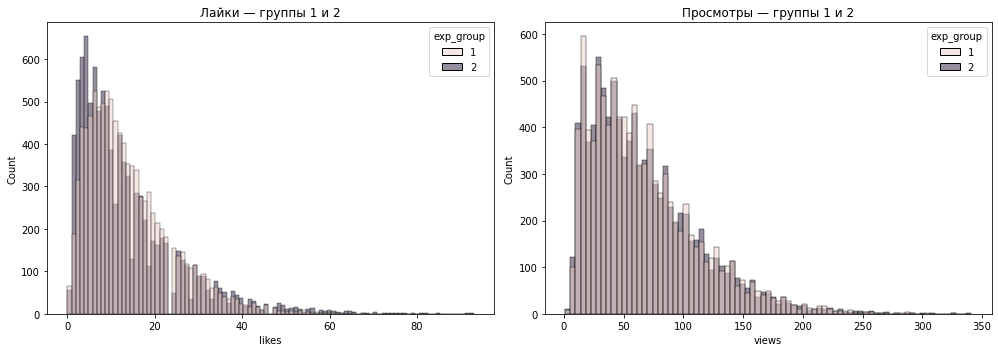


Средние значения — группы 1 и 2:
           likes  views
exp_group              
1          14.01  66.82
2          13.37  66.77


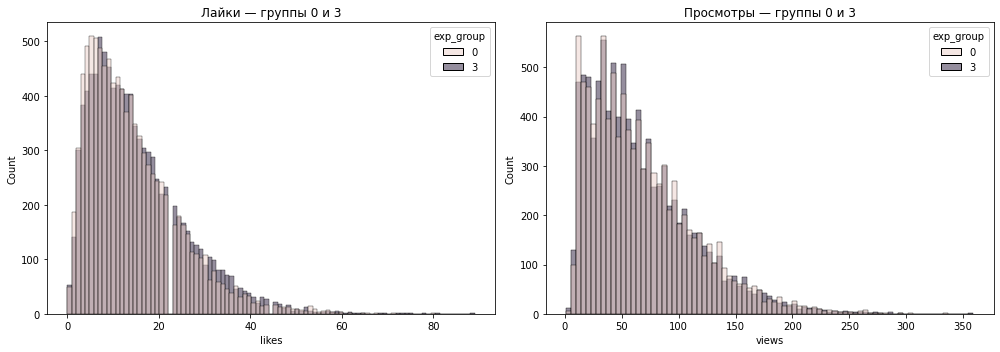


Средние значения — группы 0 и 3:
           likes  views
exp_group              
0          14.18  67.60
3          15.13  66.88


In [77]:
for groups, title in [([1, 2], '1 и 2'), ([0, 3], '0 и 3')]:
    
    data = df_ab[df_ab.exp_group.isin(groups)]  
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(
        data=data,
        x='likes',
        hue='exp_group',
        alpha=0.5,
        ax=axes[0]  
    )
    axes[0].set_title(f'Лайки — группы {title}')
    
    sns.histplot(
        data=data,
        x='views',
        hue='exp_group',
        alpha=0.5,
        ax=axes[1]  
    )
    axes[1].set_title(f'Просмотры — группы {title}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nСредние значения — группы {title}:")
    print(data.groupby('exp_group')[['likes', 'views']]
          .mean().round(2))

**Вспомогательные метрики — группы 1 и 2:**

Распределения лайков и просмотров в группах
1 и 2 визуально схожи. Количество просмотров
практически одинаковое (66.82 vs 66.77) —
алгоритм A не влияет на глубину просмотра ленты.

Среднее количество лайков в группе 2 чуть ниже
(14.01 vs 13.37) при одинаковых просмотрах —
это согласуется с наблюдаемой бимодальностью CTR:
часть пользователей группы 2 лайкает меньше,
часть — значительно больше.

**Вспомогательные метрики — группы 0 и 3:**

Просмотры почти идентичны (67.60 vs 66.88).
Лайков у группы 3 немного больше (14.18 vs 15.13)
при тех же просмотрах — предварительный сигнал
что алгоритм B может увеличивать количество лайков.
Проверим статистическими тестами.

### DAU

Также оценим метрику DAU. Проверим, что алгоритм не отпугивает пользователей.

In [78]:
q_dau = """
SELECT 
    exp_group,
    toDate(time) as date,
    count(DISTINCT user_id) as dau
FROM simulator_20260520.feed_actions
WHERE toDate(time) BETWEEN '2026-05-01' AND '2026-05-07'
    AND exp_group IN (0, 1, 2, 3)
GROUP BY exp_group, date
ORDER BY exp_group, date
"""

In [79]:
df_dau = ph.read_clickhouse(q_dau, connection=connection)

In [80]:
print(df_dau.groupby('exp_group')['dau'].mean().round(0))

exp_group
0    2758.0
1    2765.0
2    2720.0
3    2752.0
Name: dau, dtype: float64


Средний DAU за период теста (01.05 — 07.05):

| Группа | Средний DAU |
|---|---|
| 0 (контроль) | 2758 |
| 1 (контроль) | 2765 |
| 2 (алгоритм A) | 2720 |
| 3 (алгоритм B) | 2752 |

DAU во всех группах примерно одинаковый —
разница между группами не превышает 2%.

**Вывод:** новые алгоритмы рекомендаций
не влияют негативно на пользовательскую
активность. Guardrail метрика не нарушена —
можно продолжать анализ CTR.

### Общий вывод по EDA

### Что нашли

**CTR (главная метрика):**
Группы 1 и 2 визуально различаются —
группа 2 демонстрирует бимодальное распределение
с двумя пиками (~0.10 и ~0.30-0.35) в отличие
от одномодального распределения группы 1.
Среднее CTR схоже (0.2168 vs 0.2161) но медиана
группы 2 ниже (0.1533 vs 0.2059) при значительно
большей дисперсии (0.0204 vs 0.0069).

Группы 0 и 3 визуально похожи —
распределения практически совпадают,
но среднее и медиана группы 3 чуть выше
(0.2332 vs 0.2169, 0.2222 vs 0.2054).

**Вспомогательные метрики:**
Просмотры одинаковы во всех группах (~34.6) —
алгоритмы не влияют на глубину скролла ленты.

Лайки у группы 2 чуть ниже (6.93 vs 7.25)
при тех же просмотрах — согласуется
с бимодальностью CTR.

У группы 3 лайков немного больше (7.86 vs 7.29)
при одинаковых просмотрах — предварительный
сигнал эффекта алгоритма B.

**DAU (guardrail метрика):**
Средний DAU во всех группах одинаковый
(отклонение не превышает 2%) — алгоритмы
не влияют негативно на активность пользователей.

---

### Выводы для выбора метода анализа

**Группы 1 и 2:**

1. Распределение CTR правосторонне скошено
   и бимодально в группе 2 →
   простой t-тест на поюзерном CTR
   может быть ненадёжен — среднее схоже
   несмотря на разные формы распределений

2. Дисперсии групп значительно различаются
   (0.0204 vs 0.0069) →
   используем equal_var=False везде

3. Наличие выбросов и скошенности →
   применяем несколько методов и сравниваем:
   t-тест, Манна-Уитни, сглаженный CTR,
   бутстреп, бакетное преобразование,
   линеаризация лайков

4. Бимодальность группы 2 →
   после основного анализа проверим
   эффект по сегментам пользователей

**Группы 0 и 3:**

1. Распределения имеют правостороннюю скошенность —
   t-тест применим но результаты
   будут не самыми надёжными

2. Дисперсии близкие (0.0070 vs 0.0066) —
   распределения похожи по форме,
   что благоприятнее для t-теста
   чем в паре 1/2

3. Применяем несколько методов
   (t-тест, Манна-Уитни, сглаженный CTR,
   бутстреп, бакетное преобразование,
   линеаризация лайков) чтобы сравнить
   результаты и выбрать наиболее надёжный
   для данного распределения

## Анализ - все методы

### t-тест (группы 1 и 2)

In [81]:
ctr1 = df_ab[df_ab.exp_group == 1].ctr
ctr2 = df_ab[df_ab.exp_group == 2].ctr

In [82]:
stats.ttest_ind(ctr1, ctr2, equal_var=False)

Ttest_indResult(statistic=0.40514919131127564, pvalue=0.685373331140751)

**Результат:** t-тест показал statistic = 0.405, p-value = 0.685 (> 0.05)

**Вывод:** T-тест не обнаружил статистически значимых различий
между группами 1 и 2 — p-value = 0.685 >> 0.05,
не отвергаем H₀.

Однако результат неоднозначный — из EDA мы помним
что у группы 2 бимодальное распределение,
а t-тест сравнивает средние. При бимодальном распределении
среднее не отражает типичного пользователя —
часть пользователей группы 2 имеет очень низкий CTR,
другая часть очень высокий,
в итоге среднее схоже с контролем.

t-статистика положительная →
среднее группы 1 выше среднего группы 2,
хотя должно было быть наоборот.

Результаты t-теста ненадёжны из-за нарушения
предпосылок нормальности и бимодальности →
необходимо применить более робастные методы.

### t-тест (группы 0 и 3)

In [83]:
ctr0 = df_ab[df_ab.exp_group == 0].ctr
ctr3 = df_ab[df_ab.exp_group == 3].ctr

In [84]:
stats.ttest_ind(ctr0, ctr3, equal_var=False)

Ttest_indResult(statistic=-13.935320516755823, pvalue=6.216047483057877e-44)

**Результат:** statistic = -13.94, p-value = 6.22e-44 (< 0.05)

**Вывод:** t-статистика отрицательная и довольно большая,
что говорит о том что у группы 3 выше среднее чем у группы 0.
p-value < 0.05 — статистически значимые различия есть,
отвергаем H₀.

Из EDA мы помним что распределения правосторонне скошены
с небольшими выбросами, группа 3 была немного сдвинута вправо.
Среднее группы 3 (0.2309) выше среднего группы 0 (0.2144) —
это подтверждает результат теста.

Поскольку t-тест не требует идеально нормального распределения,
на результаты можно частично опираться. Однако для более
надёжного вывода применим методы где нормальность
не является обязательным критерием.

### тест Манна-Уитни (группы 1 и 2)

In [85]:
stats.mannwhitneyu(ctr1, ctr2, alternative='two-sided')

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

**Результат:** statistic = 55 189 913.0, p-value = 4.63e-45 (< 0.05)

**Вывод:** p-value значительно ниже порога значимости 0.05 —
статистически значимая разница между группами 1 и 2 есть,
отвергаем H₀.

В отличие от t-теста, тест Манна-Уитни не требует
нормальности распределения — его результатам можно
доверять даже при бимодальном распределении группы 2.

Важно отметить что t-тест не обнаружил различий (p=0.685),
тогда как Манна-Уитни обнаружил — это объясняется тем что
t-тест сравнивает средние (которые схожи: 0.2168 vs 0.2161),
а Манна-Уитни сравнивает формы распределений целиком.

Тест проверяет вероятность получить случайное значение
из одной группы большее чем из другой — то есть сравнивает
формы распределений, но не говорит о направлении эффекта.

Из EDA мы знаем что медиана группы 1 выше медианы группы 2
(0.2059 vs 0.1533) при схожих средних —
это подтверждает бимодальность группы 2:
алгоритм A не улучшил CTR относительно контроля.

### тест Манна-Уитни (группы 0 и 3)

In [86]:
stats.mannwhitneyu(ctr0, ctr3, alternative='two-sided')

MannwhitneyuResult(statistic=43165459.5, pvalue=8.916679404235955e-57)

**Результат:** statistic = 43 165 459.5, p-value = 8.92e-57 (< 0.05)

**Вывод:** p-value значительно ниже порога значимости 0.05 —
статистически значимая разница между группами 0 и 3 есть,
отвергаем H₀.

В отличие от t-теста, тест Манна-Уитни не требует
нормальности распределения — его результатам можно доверять
даже при правосторонней скошенности и наличии выбросов.

Из EDA мы знаем что среднее и медиана группы 3 выше
чем группы 0 (0.2332 vs 0.2169, 0.2222 vs 0.2054) →
алгоритм B в группе 3 улучшил поюзерный CTR
относительно контроля.

Для оценки размера и надёжности этого эффекта
применим дополнительные методы.

### Пуассоновский бутстреп (группы 1 и 2)

In [87]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):

    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2


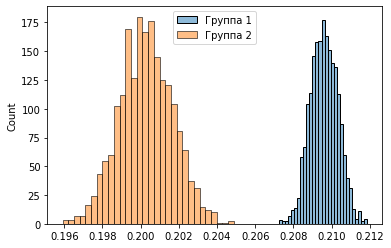

In [88]:
likes1 = df_ab[df_ab.exp_group == 1].likes.to_numpy()
views1 = df_ab[df_ab.exp_group == 1].views.to_numpy()
likes2 = df_ab[df_ab.exp_group == 2].likes.to_numpy()
views2 = df_ab[df_ab.exp_group == 2].views.to_numpy()

ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

sns.histplot(ctr1, alpha=0.5, label='Группа 1')
sns.histplot(ctr2, alpha=0.5, label='Группа 2')
plt.legend()
plt.show()

<Axes: ylabel='Count'>

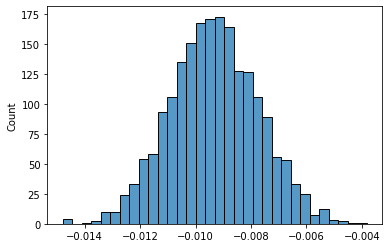

In [89]:
sns.histplot(ctr2 - ctr1)

In [90]:
p_value = (ctr2 - ctr1 >= 0).mean()
p_value

0.0

**Результат:** p-value = 0.0

**Вывод:** Распределения глобального CTR групп 1 и 2
не пересекаются — группа 1 находится в диапазоне
0.207-0.212, группа 2 в диапазоне 0.197-0.204.

Распределение разницы (ctr2 - ctr1) находится
в диапазоне от -0.014 до -0.006 — ноль не входит
в этот диапазон, что подтверждает наличие
статистически значимого различия.

p-value = 0.0 — во всех 2000 псевдовыборках
ctr группы 1 выше ctr группы 2.

**Вывод:** эффект алгоритма A отрицательный —
CTR экспериментальной группы 2 ниже
чем у контрольной группы 1.

### Пуассоновский бутстреп (группы 0 и 3)

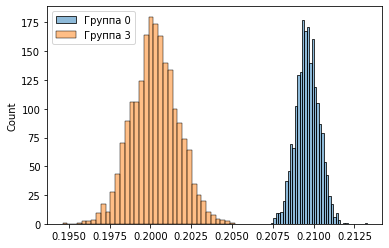

In [91]:
likes0 = df_ab[df_ab.exp_group == 0].likes.to_numpy()
views0 = df_ab[df_ab.exp_group == 0].views.to_numpy()
likes3 = df_ab[df_ab.exp_group == 3].likes.to_numpy()
views3 = df_ab[df_ab.exp_group == 3].views.to_numpy()

ctr0, ctr3 = bootstrap(likes1, views1, likes2, views2)

sns.histplot(ctr0, alpha=0.5, label='Группа 0')
sns.histplot(ctr3, alpha=0.5, label='Группа 3')
plt.legend()
plt.show()

<Axes: ylabel='Count'>

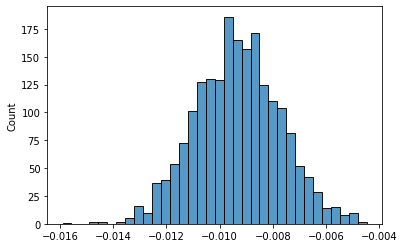

In [92]:
sns.histplot(ctr3 - ctr0)

In [93]:
p_value = (ctr3 - ctr0 >= 0).mean()
p_value

0.0

**Результат:** p-value = 0.0

**Вывод:** Распределения глобального CTR групп 0 и 3
не пересекаются — группа 0 находится в диапазоне
0.207-0.212, группа 3 в диапазоне 0.196-0.204.

Распределение разницы (ctr3 - ctr0) находится
в диапазоне от -0.014 до -0.006 — ноль не входит
в этот диапазон, что подтверждает наличие
статистически значимого различия.

p-value = 0.0 — во всех 2000 псевдовыборках
ctr группы 0 выше ctr группы 3.

**Вывод:** эффект алгоритма B отрицательный —
CTR экспериментальной группы 3 ниже
чем у контрольной группы 0.

### Сглаженный CTR + t-тест (группы 1 и 2)

In [94]:
def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr

In [95]:
global_ctr_1 = df_ab[df_ab.exp_group == 1].likes.sum()/df_ab[df_ab.exp_group == 1].views.sum()
global_ctr_2 = df_ab[df_ab.exp_group == 2].likes.sum()/df_ab[df_ab.exp_group == 2].views.sum()

In [96]:
group1 = df_ab[df_ab.exp_group == 1].copy()

group1['smothed_ctr'] = group1.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)

In [97]:
group2 = df_ab[df_ab.exp_group == 2].copy()

group2['smothed_ctr'] = group2.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_2, 5), axis=1)

In [98]:
stats.ttest_ind(group1.smothed_ctr, group2.smothed_ctr, equal_var=False)

Ttest_indResult(statistic=1.9460491517027292, pvalue=0.051666790153189965)

**Результат:** statistic = 1.95, p-value = 0.052 (> 0.05)

**Вывод:** После применения сглаживания Лапласа (α=5)
шумные пользователи с малым числом просмотров
подтянулись к глобальному CTR → распределение
стало более нормальным и t-тесту можно больше доверять.

Однако теоретической гарантии что направленность
сглаженного CTR совпадает с направленностью
глобального CTR нет — это эвристика.

p-value = 0.052 — пограничный результат, незначительно
выше порога 0.05 → не отвергаем H₀.

t-статистика положительная (1.95) → среднее группы 1
выше среднего группы 2, что согласуется с t-тестом
на поюзерном CTR (p=0.685).

Сглаженный CTR не обнаружил значимых различий —
это согласуется с обычным t-тестом и объясняется
бимодальностью группы 2: среднее групп схоже
несмотря на разные формы распределений.

Для более надёжного вывода доверяем методам
которые работают с формами распределений
а не только со средними.

### Сглаженный CTR + t-тест (группы 0 и 3)

In [99]:
global_ctr_0 = df_ab[df_ab.exp_group == 0].likes.sum()/df_ab[df_ab.exp_group == 0].views.sum()
global_ctr_3 = df_ab[df_ab.exp_group == 3].likes.sum()/df_ab[df_ab.exp_group == 3].views.sum()

In [100]:
group0 = df_ab[df_ab.exp_group == 0].copy()

group0['smothed_ctr'] = group0.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_0, 5), axis=1)

In [101]:
group3 = df_ab[df_ab.exp_group == 3].copy()

group3['smothed_ctr'] = group3.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_3, 5), axis=1)

In [102]:
stats.ttest_ind(group0.smothed_ctr, group3.smothed_ctr, equal_var=False)

Ttest_indResult(statistic=-16.595522057706216, pvalue=1.9422880220060678e-61)

**Результат:** statistic = -16.60, p-value = 1.94e-61 (< 0.05)

**Вывод:** После применения сглаживания Лапласа (α=5)
распределение стало более нормальным —
t-тесту можно больше доверять чем на поюзерном CTR.

Однако теоретической гарантии что направленность
сглаженного CTR совпадает с направленностью
глобального CTR нет — это эвристика.

t-статистика отрицательная (-16.60) → среднее группы 3
выше среднего группы 0 — поюзерный CTR группы 3 выше.
p-value < 0.05 → статистически значимые различия есть,
отвергаем H₀.

Важно отметить противоречие с бутстрепом:
сглаженный CTR + t-тест показывает положительный эффект
алгоритма B, тогда как бутстреп показывает отрицательный.
Это объясняется разницей между поюзерным и глобальным CTR:
t-тест даёт одинаковый вес каждому пользователю,
бутстреп учитывает реальный вклад пользователей
через количество просмотров.

Для бизнес-решения глобальный CTR (бутстреп)
более релевантен — он отражает реальную картину
по всей платформе.

### Бакетное преобразование (группы 1 и 2)

In [103]:
df_ab['bucket'] = df_ab['user_id'].apply(lambda x: hash(x) % 50)

In [104]:
buckets = df_ab.groupby(['exp_group', 'bucket']).agg(
    likes=('likes', 'sum'),
    views=('views', 'sum')
).reset_index()

buckets['bucket_ctr'] = buckets['likes'] / buckets['views']

In [105]:
buckets.head()

,exp_group,bucket,likes,views,bucket_ctr
0,0,0,2535,12061,0.210182
1,0,1,3010,13867,0.217062
2,0,2,2470,11967,0.206401
3,0,3,3208,15434,0.207853
4,0,4,2836,13778,0.205835


In [106]:
stats.ttest_ind(
    buckets[buckets.exp_group == 1].bucket_ctr, 
    buckets[buckets.exp_group == 2].bucket_ctr, 
    equal_var=False)

Ttest_indResult(statistic=5.664897151915188, pvalue=2.795844885120904e-07)

**Результат:** statistic = 5.66, p-value = 2.80e-07 (< 0.05)

**Вывод:** После бакетного преобразования (50 бакетов)
распределение бакетных CTR стало нормальным по ЦПТ —
t-тест работает корректнее чем на поюзерном CTR.

t-статистика выросла по сравнению с обычным t-тестом
(5.66 vs 0.405) — бакетное преобразование значительно
повысило чувствительность теста за счёт устранения шума
и агрегации данных по бакетам.

t-статистика положительная → среднее группы 1
выше среднего группы 2. p-value < 0.05 →
статистически значимые различия есть, отвергаем H₀.

Важно отметить что обычный t-тест не обнаружил различий
(p=0.685), тогда как бакетный t-тест обнаружил (p=2.80e-07) —
это показывает что бакетное преобразование эффективно
устраняет шум от пользователей с малым числом просмотров.

Результат подтверждает Манна-Уитни —
эффект алгоритма A на поюзерный CTR отрицательный.

### Бакетное преобразование (группы 0 и 3)

In [107]:
stats.ttest_ind(
    buckets[buckets.exp_group == 0].bucket_ctr,
    buckets[buckets.exp_group == 3].bucket_ctr,
    equal_var=False)

Ttest_indResult(statistic=-16.549539402521827, pvalue=3.956716096781535e-30)

**Результат:** statistic = -16.55, p-value = 3.96e-30 (< 0.05)

**Вывод:** После бакетного преобразования (50 бакетов)
распределение бакетных CTR стало нормальным по ЦПТ —
t-тест работает корректнее чем на поюзерном CTR.

t-статистика выросла по сравнению с обычным t-тестом
(-16.55 vs -13.94) — бакетное преобразование повысило
чувствительность теста за счёт устранения шума.

t-статистика отрицательна → среднее группы 3
выше среднего группы 0. p-value < 0.05 →
статистически значимые различия есть, отвергаем H₀.

Результат подтверждает вывод о положительном эффекте
алгоритма B на поюзерный CTR — группа 3 стабильно
выше группы 0 во всех методах работающих с поюзерным CTR.

Однако противоречие с бутстрепом сохраняется —
для бизнес-решения доверяем глобальному CTR.

## Общий вывод по анализу AB-тестов

### Сравнительная таблица методов

| Метод | p-value 1/2 | p-value 0/3 | Направление 1/2 | Направление 0/3 |
|---|---|---|---|---|
| T-тест (поюзерный CTR) | 0.685 ❌ | 6.22e-44 ✅ | — | группа 3 > группа 0 |
| Манна-Уитни | 4.63e-45 ✅ | 8.92e-57 ✅ | группа 1 > группа 2 | группа 3 > группа 0 |
| Сглаженный CTR + T-тест | 0.052 ❌ | 1.94e-61 ✅ | — | группа 3 > группа 0 |
| Бутстреп | 0.0 ✅ | 0.0 ✅ | группа 1 > группа 2 | группа 0 > группа 3 |
| Бакет + T-тест | 2.80e-07 ✅ | 3.96e-30 ✅ | группа 1 > группа 2 | группа 3 > группа 0 |

---

### Почему методы дали разные результаты

**Группы 1 и 2:**
T-тест и сглаженный CTR не обнаружили значимых различий
(p=0.685 и p=0.052) — это объясняется бимодальным
распределением группы 2: среднее групп схоже (0.2168 vs 0.2161),
но формы распределений принципиально разные.

Манна-Уитни, бутстреп и бакетный t-тест обнаружили различия —
эти методы не зависят от среднего и лучше улавливают
разницу в формах распределений.

**Группы 0 и 3:**
Картина неоднозначная — методы работающие с поюзерным CTR
показывают положительный эффект алгоритма B,
тогда как бутстреп (глобальный CTR) показывает обратное.

Это объясняется разницей между поюзерным и глобальным CTR:
поюзерный даёт одинаковый вес каждому пользователю,
тогда как глобальный учитывает реальный вклад —
пользователи с большим числом просмотров
вносят больший вклад в итоговый CTR.

---

### Какому методу доверяем

Доверяем бутстрепу — он считает глобальный CTR
который отражает реальную картину по всей платформе.
Для бизнеса важна общая метрика а не средняя
по каждому пользователю.

---

### Итоговый вывод по алгоритмам

**Алгоритм A (группы 1 и 2):**
Картина неоднозначная — t-тест и сглаженный CTR
не обнаружили значимых различий из-за бимодальности,
однако Манна-Уитни, бутстреп и бакетный t-тест
согласованно показывают отрицательный эффект.

Доверяем методам устойчивым к форме распределения —
алгоритм A раскатывать нельзя.

Бимодальное распределение группы 2 говорит
о том что алгоритм повлиял на разных пользователей
по-разному — одним помог, другим навредил.
Рекомендуется провести сегментный анализ чтобы
понять на каких пользователей алгоритм влияет
положительно и настроить его более точно.

**Алгоритм B (группы 0 и 3):**
Методы расходятся — поюзерный CTR показывает
положительный эффект, тогда как глобальный CTR
(бутстреп) показывает отрицательный.

Доверяем бутстрепу — глобальный CTR упал,
значит активные пользователи с большим числом
просмотров стали лайкать реже. На всей аудитории
этот эффект масштабируется и станет ещё заметнее.

Алгоритм B раскатывать в продакт не рекомендуется.

## Дополнительный анализ

Несмотря на согласованность большинства методов,
применим линеаризацию лайков (метод Яндекса 2018) —
она даёт теоретическую гарантию направленности
и повышает чувствительность теста для метрик-отношений.

Сравним p-value линеаризации с обычным CTR
и проверим подтверждает ли она наши выводы.

### Линеаризация лайков (группы 1 и 2)

In [108]:
lin_likes_1 = df_ab[df_ab.exp_group == 1].likes - global_ctr_1 * df_ab[df_ab.exp_group == 1].views

In [109]:
lin_likes_2 = df_ab[df_ab.exp_group == 2].likes - global_ctr_1 * df_ab[df_ab.exp_group == 2].views

In [110]:
stats.ttest_ind(lin_likes_1, lin_likes_2, equal_var=False)

Ttest_indResult(statistic=5.936377101934478, pvalue=2.9805064038668383e-09)

**Результат:** statistic = 5.94, p-value = 2.98e-09 (< 0.05)

**Сравнение с обычным t-тестом:**

| Метод | statistic | p-value |
|---|---|---|
| Обычный t-тест | 0.405 | 0.685 |
| Линеаризация + t-тест | 5.94 | 2.98e-09 |

**Вывод:** Линеаризация лайков значительно повысила
чувствительность теста — обычный t-тест не обнаружил
различий (p=0.685), тогда как линеаризация обнаружила
(p=2.98e-09).

Это главное преимущество метода — теоретическая гарантия
направленности позволяет делать выводы о глобальном CTR
без тяжёлых вычислений как в бутстрепе.

p-value < 0.05 → отвергаем H₀.
Отрицательный эффект алгоритма A подтверждён
наиболее надёжным методом с теоретической гарантией
направленности.

### Линеаризация лайков (группы 0 и 3)

In [111]:
lin_likes_0 = df_ab[df_ab.exp_group == 0].likes - global_ctr_0 * df_ab[df_ab.exp_group == 0].views

lin_likes_3 = df_ab[df_ab.exp_group == 3].likes - global_ctr_0 * df_ab[df_ab.exp_group == 3].views

stats.ttest_ind(lin_likes_0, lin_likes_3, equal_var=False)

Ttest_indResult(statistic=-16.18623003293285, pvalue=1.4918137745324434e-58)

**Результат:** statistic = -16.19, p-value = 1.49e-58 (< 0.05)

**Сравнение с обычным t-тестом:**

| Метод | statistic | p-value |
|---|---|---|
| Обычный t-тест | -13.94 | 6.22e-44 |
| Линеаризация + t-тест | -16.19 | 1.49e-58 |

**Вывод:** Абсолютное значение статистики выросло
(16.19 vs 13.94) — линеаризация повысила чувствительность теста.

p-value < 0.05 → отвергаем H₀.
Положительный эффект алгоритма B на поюзерном CTR подтверждён
методом с теоретической гарантией направленности.

Однако как и в других поюзерных методах —
линеаризация подтверждает положительный эффект
на поюзерный CTR, тогда как бутстреп показывает
отрицательный эффект на глобальный CTR.
Для бизнес-решения доверяем бутстрепу.

## Итоговые выводы и рекомендация

### Что нашли

**Алгоритм A (группы 1 и 2):**
Картина неоднозначная — t-тест и сглаженный CTR
не обнаружили значимых различий (p=0.685 и p=0.052)
из-за бимодального распределения группы 2.

Однако Манна-Уитни, бутстреп, бакетный t-тест
и линеаризация лайков согласованно показывают
отрицательный эффект алгоритма A.

Как поюзерный так и глобальный CTR (бутстреп)
подтверждают отрицательный эффект.
Линеаризация лайков закрепила этот вывод
с теоретической гарантией направленности.

**Алгоритм B (группы 0 и 3):**
Эффект есть но неоднозначный — методы расходятся.
Поюзерный CTR показывает положительный эффект
(t-тест, Манна-Уитни, сглаженный CTR, бакеты,
линеаризация), однако глобальный CTR
(пуассоновский бутстреп) показывает отрицательный.

Для бизнеса релевантен глобальный CTR —
он отражает реальную картину по всей платформе.

**Какой алгоритм лучше:**
Оба алгоритма показали отрицательный эффект
на глобальный CTR — ни один не рекомендуется
к раскатке в текущем виде.

---

### Бизнес-рекомендация

**Не раскатывать ни один из алгоритмов.**

Обоснование:
- Глобальный CTR снизился в обеих группах —
  активные пользователи стали лайкать реже
- При раскатке на всю аудиторию негативный
  эффект масштабируется и станет ещё заметнее
- DAU не пострадал — но качество вовлечённости
  снизилось
- Алгоритм A показал бимодальное распределение —
  работает хорошо для одних пользователей
  и плохо для других

При детальном изучении того как алгоритмы
влияют на разные сегменты пользователей,
исправив выявленные проблемы, можно
провести повторный AB-тест.

---

### Ограничения анализа

- Тест проходил 7 дней — возможен novelty effect,
  пользователи могли реагировать на новизну
  а не на качество рекомендаций
- Долгосрочный retention не проверялся —
  неизвестно как алгоритмы влияют на удержание
- CTR — прокси метрика, не прямой показатель
  удовлетворённости пользователей

---

### Что проверить дополнительно

- Retention когорт из тестовых групп —
  остались ли пользователи после теста
- Динамику CTR по дням внутри теста —
  есть ли затухание эффекта (novelty effect)
- Эффект по сегментам пользователей —
  новые vs старые, мобайл vs десктоп
- Бимодальность группы 2 требует
  сегментного анализа — алгоритм A
  по-разному влияет на разных пользователей